In [10]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings(
    "ignore",
    message="Could not infer format",
    category=UserWarning
)


file_path = "/Users/linhhuynh/Desktop/DSC680/W 5 to 8/Border_Crossing_Entry_Data.csv"
df = pd.read_csv(file_path)

# Clean column names
df.columns = df.columns.str.strip()

print("Raw shape:", df.shape)
print("Raw columns:", df.columns.tolist())

Raw shape: (346733, 8)
Raw columns: ['Port Name', 'State', 'Port Code', 'Border', 'Date', 'Measure', 'Value', 'Location']


In [12]:
# Data Prep
# Date Parse 
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Value Parse
df["Value"] = (
    df["Value"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

# Clean Text Columns 
for col in ["Border", "Measure", "Port Code", "Port Name", "State"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# Drop Invalid Rows
df = df.dropna(subset=["Date", "Value", "Border", "Measure", "Port Code"])
df = df[df["Value"] >= 0].copy()

# Time Features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

# Freight Filter
df = df[
    df["Measure"].str.contains(
        r"truck|rail|train|container",
        case=False,
        na=False,
        regex=True
    )
].copy()

# Aggregate Duplicates
group_cols = [
    "Port Code", "Port Name", "State",
    "Border", "Date", "Year", "Month", "Measure"
]

df = df.groupby(group_cols, as_index=False)["Value"].sum()

# Final Check
print("\nCleaned shape:", df.shape)
print("Date range:", df["Date"].min(), "to", df["Date"].max())
print("\nMeasures kept:")
print(df["Measure"].value_counts().head(10))

df.head()


Cleaned shape: (199979, 9)
Date range: 1996-01-01 00:00:00 to 2019-03-01 00:00:00

Measures kept:
Measure
Trucks                    29856
Truck Containers Empty    29757
Truck Containers Full     29694
Trains                    27708
Rail Containers Empty     27684
Rail Containers Full      27657
Train Passengers          27623
Name: count, dtype: int64


,Port Code,Port Name,State,Border,Date,Year,Month,Measure,Value
0,101,Portland,Maine,US-Canada Border,1996-01-01,1996,1,Rail Containers Empty,0
1,101,Portland,Maine,US-Canada Border,1996-01-01,1996,1,Rail Containers Full,0
2,101,Portland,Maine,US-Canada Border,1996-01-01,1996,1,Train Passengers,0
3,101,Portland,Maine,US-Canada Border,1996-01-01,1996,1,Trains,0
4,101,Portland,Maine,US-Canada Border,1996-01-01,1996,1,Truck Containers Empty,0


In [14]:
df = df[df["Measure"] != "Train Passengers"].copy()

print("Measures after fix:")
print(df["Measure"].value_counts())

Measures after fix:
Measure
Trucks                    29856
Truck Containers Empty    29757
Truck Containers Full     29694
Trains                    27708
Rail Containers Empty     27684
Rail Containers Full      27657
Name: count, dtype: int64


In [16]:
# EDA
# Truck vs Rail by Border - Which border has more activity?
# Create Mode (Truck vs Rail)
df["Mode"] = np.where(
    df["Measure"].str.contains("Truck", case=False),
    "Truck",
    "Rail"
)

# Aggregate total volume by Border and Mode
border_mode = (
    df.groupby(["Border", "Mode"])["Value"]
    .sum()
    .reset_index()
)

# Pivot for plotting
border_pivot = border_mode.pivot(
    index="Border", columns="Mode", values="Value"
)

border_pivot

Mode,Rail,Truck
Border,,
US-Canada Border,43512835,273447498
US-Mexico Border,16818866,221442985


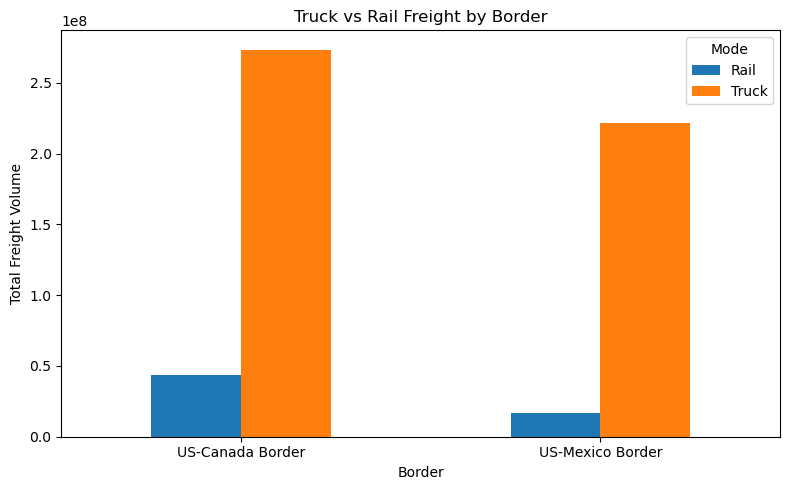

In [18]:
# Plot
border_pivot.plot(kind="bar", figsize=(8,5))
plt.title("Truck vs Rail Freight by Border")
plt.xlabel("Border")
plt.ylabel("Total Freight Volume")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

This chart compares total truck and rail freight volume at the U.S.-Canada and U.S.–Mexico borders. Truck traffic is much higher than rail traffic at both borders, showing that trucks are the main way freight crosses U.S. borders. The Canada border handles more rail freight, while the Mexico border relies more heavily on truck transportation.

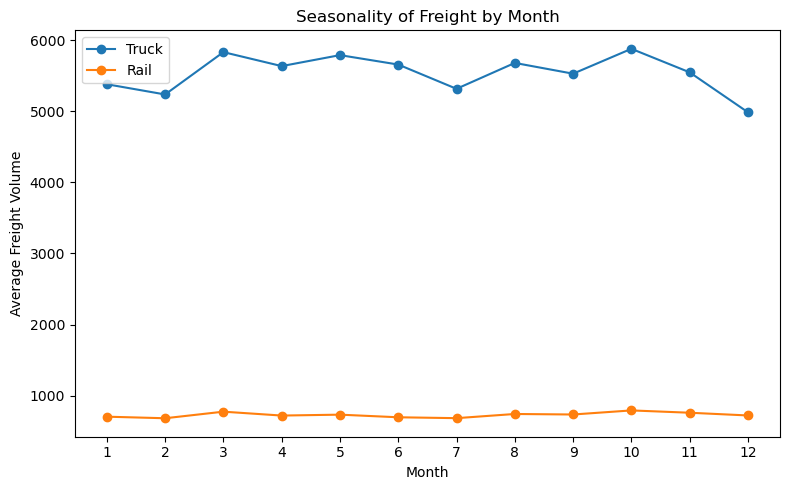

In [20]:
# Seasonality by Month - Are there peak months for truck or rail freight?
# Average monthly volume by mode
seasonality = (
    df.groupby(["Month", "Mode"])["Value"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
for mode in ["Truck", "Rail"]:
    subset = seasonality[seasonality["Mode"] == mode]
    plt.plot(subset["Month"], subset["Value"], marker="o", label=mode)

plt.title("Seasonality of Freight by Month")
plt.xlabel("Month")
plt.ylabel("Average Freight Volume")
plt.xticks(range(1, 13))
plt.legend()
plt.tight_layout()
plt.show()

This chart shows the average monthly freight volume for truck and rail transportation. Both truck and rail traffic follow a seasonal pattern, with higher volumes in spring and fall and lower volumes in summer and December. This suggests that freight activity changes by season and can be planned for staffing and resources in advance.

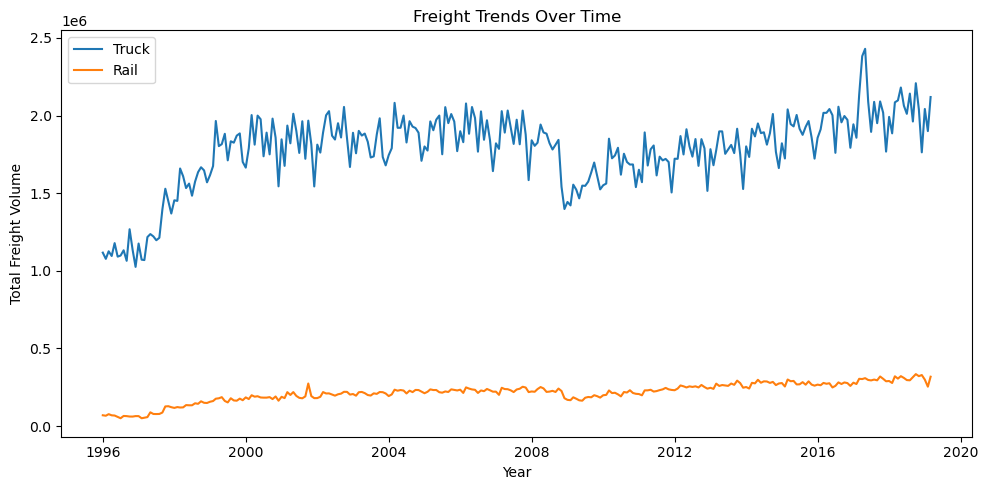

In [24]:
# Trends Over Time - Is freight increasing or decreasing over time?
# Monthly total freight volume by mode
trend = (
    df.groupby(["Date", "Mode"])["Value"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,5))
for mode in ["Truck", "Rail"]:
    subset = trend[trend["Mode"] == mode]
    plt.plot(subset["Date"], subset["Value"], label=mode)

plt.title("Freight Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Total Freight Volume")
plt.legend()
plt.tight_layout()
plt.show()

This chart shows total monthly freight volume for truck and rail transportation over time. Both modes increase over the long term, but there is a noticeable drop around 2008-2009, likely due to economic slowdown. After this period, freight volume recovers and continues to grow, showing long-term growth in cross-border trade.

In [26]:
# Top Ports by Freight Volume - Which ports handle the most freight?
# Total freight volume per port
top_ports = (
    df.groupby(["Port Name", "State"])["Value"]
    .sum()
    .reset_index()
    .sort_values("Value", ascending=False)
)

top_ports.head(10)

,Port Name,State,Value
50,Laredo,Texas,82254740
27,Detroit,Michigan,75708089
14,Buffalo-Niagara Falls,New York,48033836
77,Port Huron,Michigan,45547225
33,El Paso,Texas,34736287
71,Otay Mesa,California,34619806
43,Hidalgo,Texas,20556744
9,Blaine,Washington,20312839
20,Champlain-Rouses Point,New York,16660737
63,Nogales,Arizona,14594144


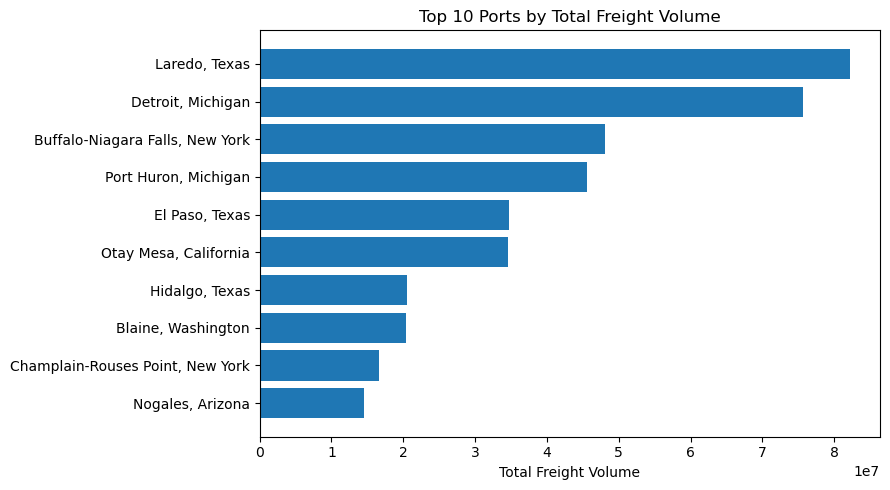

In [28]:
top_10 = top_ports.head(10)

plt.figure(figsize=(9,5))
plt.barh(
    top_10["Port Name"] + ", " + top_10["State"],
    top_10["Value"]
)
plt.gca().invert_yaxis()
plt.title("Top 10 Ports by Total Freight Volume")
plt.xlabel("Total Freight Volume")
plt.tight_layout()
plt.show()

This chart shows the top 10 ports by total freight volume. Freight traffic is concentrated at a small number of ports, with Laredo, Texas handling the most volume. Several of the busiest ports are located on the U.S.–Mexico border, while major Canada border ports such as Detroit and Buffalo–Niagara Falls also play an important role. These ports are key locations for trade and should be prioritized for planning and investment.

In [33]:
# Forecasting - Use simple baseline models to forecast monthly freight volume and compare their accuracy.

# Prepare Monthly Time Series (Total Freight)
# Aggregate total freight by month (all ports, truck + rail)
monthly = (
    df.groupby("Date")["Value"]
    .sum()
    .reset_index()
    .sort_values("Date")
)

# Create time features
monthly["t"] = np.arange(len(monthly))          # time index
monthly["Month"] = monthly["Date"].dt.month     # seasonality

monthly.head()

,Date,Value,t,Month
0,1996-01-01,1187040,0,1
1,1996-02-01,1144106,1,2
2,1996-03-01,1202896,2,3
3,1996-04-01,1165057,3,4
4,1996-05-01,1246663,4,5


In [35]:
# Seasonal Naive Forecast - Use the same month from the previous year as the prediction.
monthly["Seasonal_Naive"] = monthly["Value"].shift(12)

monthly[["Date", "Value", "Seasonal_Naive"]].head(15)

,Date,Value,Seasonal_Naive
0,1996-01-01,1187040,NaN
1,1996-02-01,1144106,NaN
2,1996-03-01,1202896,NaN
3,1996-04-01,1165057,NaN
4,1996-05-01,1246663,NaN
5,1996-06-01,1150991,NaN
6,1996-07-01,1149263,NaN
7,1996-08-01,1197746,NaN
8,1996-09-01,1128891,NaN
9,1996-10-01,1329580,NaN


In [37]:
# Linear Regression (Time + Month)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Keep rows where seasonal naive exists (fair comparison)
model_df = monthly.dropna().copy()

X = model_df[["t", "Month"]]
y = model_df["Value"]

lr = LinearRegression()
lr.fit(X, y)

model_df["LR_Pred"] = lr.predict(X)

In [39]:
# Model Evaluation (MAE / RMSE)
# Seasonal Naive metrics
mae_naive = mean_absolute_error(
    model_df["Value"], model_df["Seasonal_Naive"]
)
rmse_naive = mean_squared_error(
    model_df["Value"], model_df["Seasonal_Naive"], squared=False
)

# Linear Regression metrics
mae_lr = mean_absolute_error(
    model_df["Value"], model_df["LR_Pred"]
)
rmse_lr = mean_squared_error(
    model_df["Value"], model_df["LR_Pred"], squared=False
)

print("Forecast Accuracy:")
print(f"Seasonal Naive  | MAE: {mae_naive:,.0f} | RMSE: {rmse_naive:,.0f}")
print(f"Linear Reg.     | MAE: {mae_lr:,.0f} | RMSE: {rmse_lr:,.0f}")

Forecast Accuracy:
Seasonal Naive  | MAE: 119,778 | RMSE: 167,073
Linear Reg.     | MAE: 162,397 | RMSE: 208,013


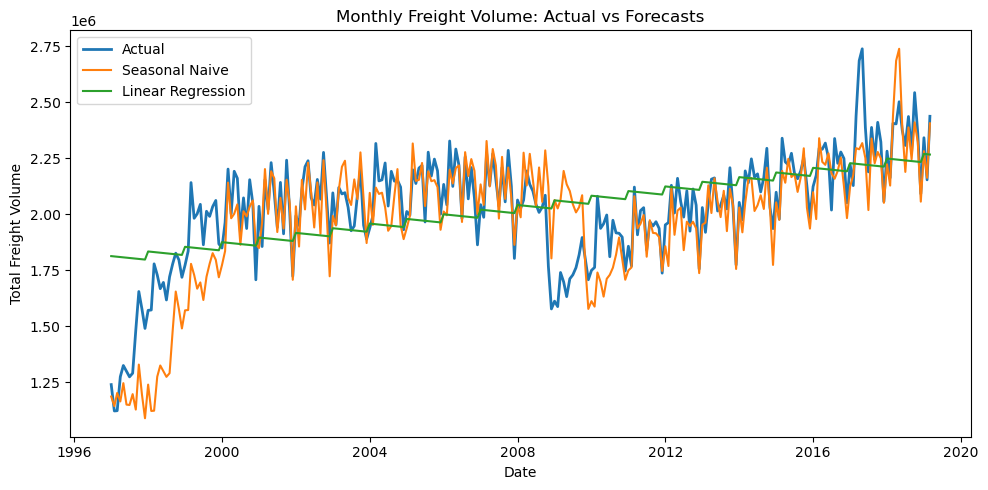

In [41]:
# Forecast Comparison Plot
plt.figure(figsize=(10,5))
plt.plot(model_df["Date"], model_df["Value"], label="Actual", linewidth=2)
plt.plot(model_df["Date"], model_df["Seasonal_Naive"], label="Seasonal Naive")
plt.plot(model_df["Date"], model_df["LR_Pred"], label="Linear Regression")

plt.title("Monthly Freight Volume: Actual vs Forecasts")
plt.xlabel("Date")
plt.ylabel("Total Freight Volume")
plt.legend()
plt.tight_layout()
plt.show()

Two forecasting models were compared using MAE and RMSE. The seasonal naive model had lower error than the linear regression model, which shows that monthly freight volume follows strong seasonal patterns. This result suggests that simple baseline models can be effective for short-term freight planning.

In [44]:
# Clustering Ports by Usage Patterns - 
# Group ports based on their average truck and rail freight activity to identify different usage patterns.

# Prepare Port-Level Features (Avg Truck & Rail)
# Average freight volume per port by mode
port_avg = (
    df.groupby(["Port Code", "Port Name", "Mode"])["Value"]
    .mean()
    .reset_index()
)

# Pivot to wide format: Truck vs Rail
port_pivot = (
    port_avg.pivot(
        index=["Port Code", "Port Name"],
        columns="Mode",
        values="Value"
    )
    .fillna(0)
)

port_pivot.head()

,Mode,Rail,Truck
Port Code,Port Name,,
101,Portland,0.000000,2.192790
103,Eastport,0.000000,138.726496
104,Jackman,524.240143,4999.375149
105,Vanceboro,436.652330,194.903962
106,Houlton,0.079622,5447.684588


In [46]:
# Scale Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(port_pivot[["Truck", "Rail"]])

In [48]:
# Apply K-Means (k = 3)
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

port_pivot["Cluster"] = clusters

In [49]:
# Silhouette Score
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score (k=3):", round(sil_score, 3))

Silhouette Score (k=3): 0.807


In [52]:
# Interpret Clusters (Average Volumes)
cluster_summary = (
    port_pivot.groupby("Cluster")[["Truck", "Rail"]]
    .mean()
    .sort_index()
)

cluster_summary

Mode,Truck,Rail
Cluster,,
0,1494.549095,96.156316
1,72443.438072,8603.974910
2,20443.640925,3400.275243


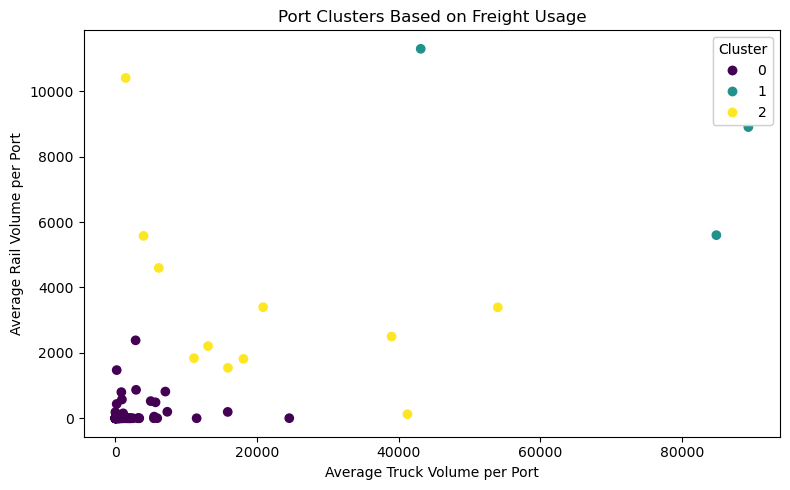

In [57]:
plt.figure(figsize=(8,5))

scatter = plt.scatter(
    port_pivot["Truck"],
    port_pivot["Rail"],
    c=port_pivot["Cluster"],
    cmap="viridis"
)

plt.xlabel("Average Truck Volume per Port")
plt.ylabel("Average Rail Volume per Port")
plt.title("Port Clusters Based on Freight Usage")

legend = plt.legend(
    *scatter.legend_elements(),
    title="Cluster"
)
plt.gca().add_artist(legend)

plt.tight_layout()
plt.show()


Ports were grouped into three clusters based on their average truck and rail freight volumes. Cluster 0 represents smaller, truck-focused ports with little rail activity. Cluster 2 includes medium-volume ports that use both truck and rail. Cluster 1 represents major freight hubs with very high activity in both modes. These clusters help identify which ports require different levels of investment and operational focus.